<a href="https://colab.research.google.com/github/Borissohi01/Ibm_t1/blob/main/projetdash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import io
import requests
import pandas as pd

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

# Fetch the data using requests
response = requests.get(URL)
response.raise_for_status()  # Raise an exception for bad responses

# Read the data into a pandas DataFrame
text = io.BytesIO(response.content)
df = pd.read_csv(text)

print('Data downloaded and read into a dataframe!')

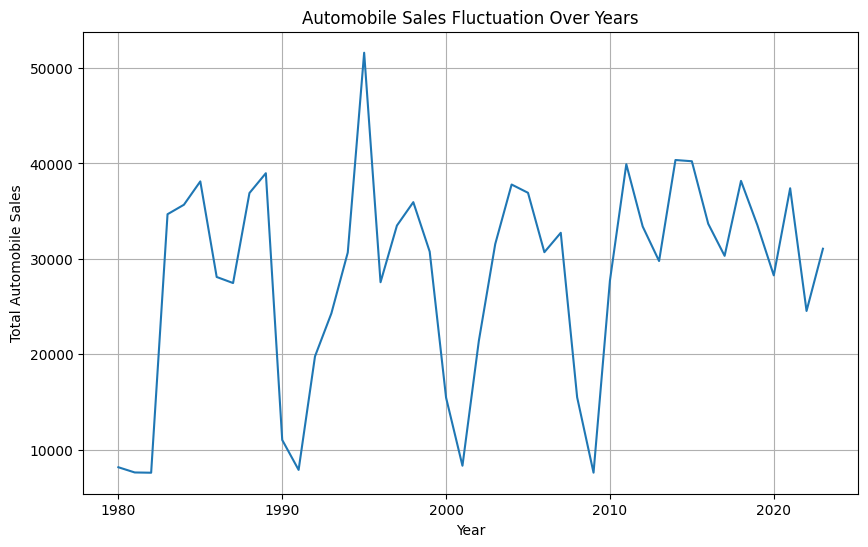

In [10]:
import matplotlib.pyplot as plt

# Group data by year and sum sales
yearly_sales = df.groupby('Year')['Automobile_Sales'].sum()

# Create the line plot
yearly_sales.plot(kind='line', figsize=(10, 6))
plt.title('Automobile Sales Fluctuation Over Years')
plt.xlabel('Year')
plt.ylabel('Total Automobile Sales')
plt.grid(True)
plt.show()

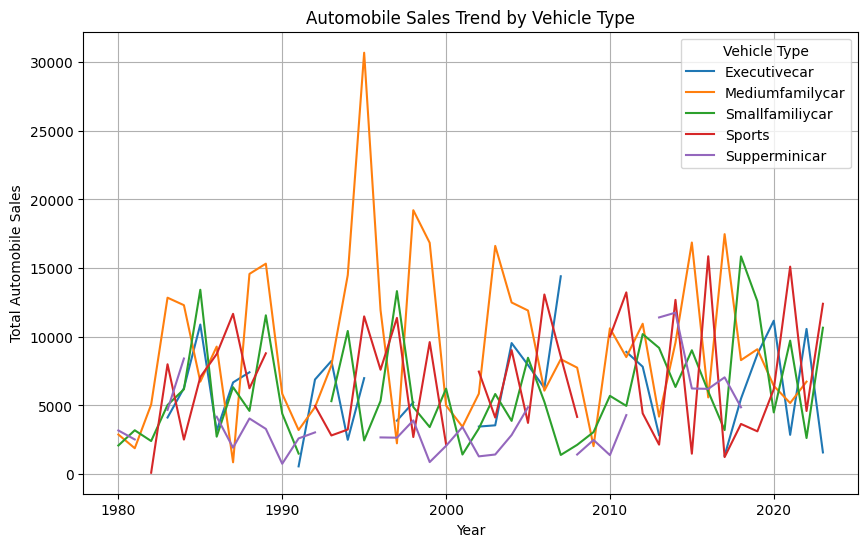

In [11]:
# Group data by year and vehicle type, then sum sales
vehicle_sales = df.groupby(['Year', 'Vehicle_Type'])['Automobile_Sales'].sum().unstack()

# Create the line plot
vehicle_sales.plot(kind='line', figsize=(10, 6))
plt.title('Automobile Sales Trend by Vehicle Type')
plt.xlabel('Year')
plt.ylabel('Total Automobile Sales')
plt.legend(title='Vehicle Type')
plt.grid(True)
plt.show()



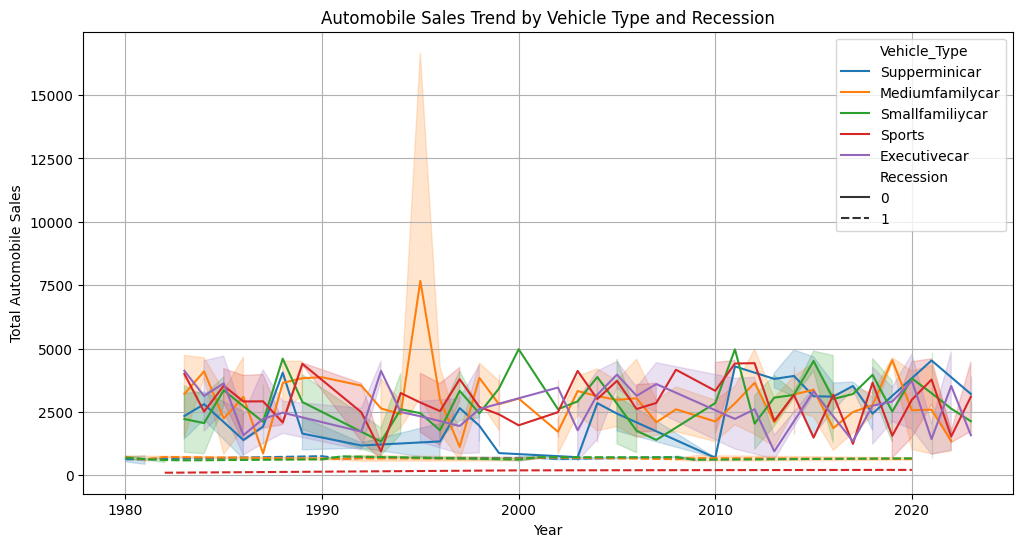

In [12]:

# Create the Seaborn plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Automobile_Sales', hue='Vehicle_Type', style='Recession', data=df)
plt.title('Automobile Sales Trend by Vehicle Type and Recession')
plt.xlabel('Year')
plt.ylabel('Total Automobile Sales')
plt.grid(True)
plt.show()

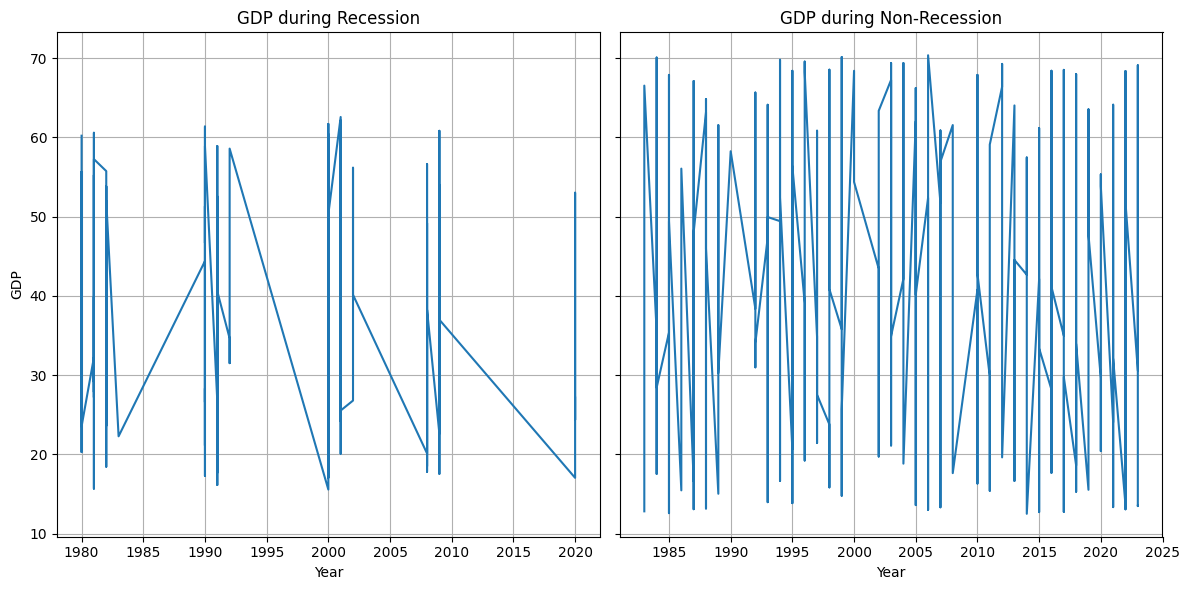

In [13]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Plot for recession periods
recession_data = df[df['Recession'] == 1]
axes[0].plot(recession_data['Year'], recession_data['GDP'], label='Recession')
axes[0].set_title('GDP during Recession')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP')
axes[0].grid(True)

# Plot for non-recession periods
non_recession_data = df[df['Recession'] == 0]
axes[1].plot(non_recession_data['Year'], non_recession_data['GDP'], label='Non-Recession')
axes[1].set_title('GDP during Non-Recession')
axes[1].set_xlabel('Year')
axes[1].grid(True)

plt.tight_layout()
plt.show()

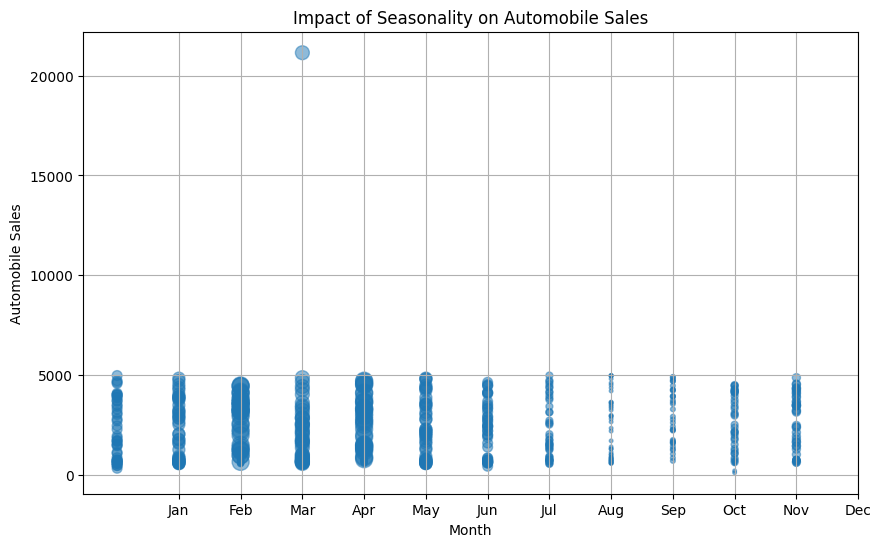

In [14]:

# Create the bubble chart
plt.figure(figsize=(10, 6))
plt.scatter(df['Month'], df['Automobile_Sales'], s=df['Seasonality_Weight'] * 100, alpha=0.5)
plt.title('Impact of Seasonality on Automobile Sales')
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

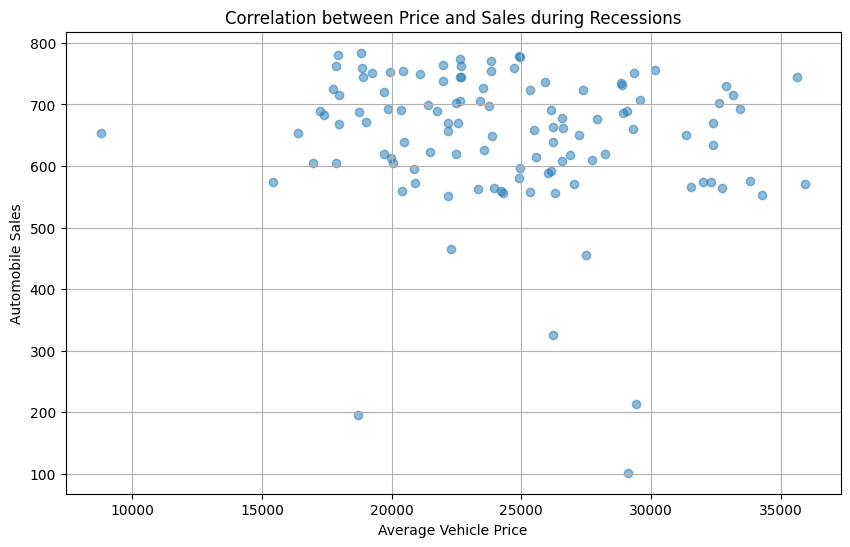

In [15]:

# Filter data for recession periods
recession_data = df[df['Recession'] == 1]

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(recession_data['Price'], recession_data['Automobile_Sales'], alpha=0.5)
plt.title('Correlation between Price and Sales during Recessions')
plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales')
plt.grid(True)
plt.show()

# Analyze the scatter plot to identify any correlation (positive, negative, or no correlation)
# between price and sales during recession periods.

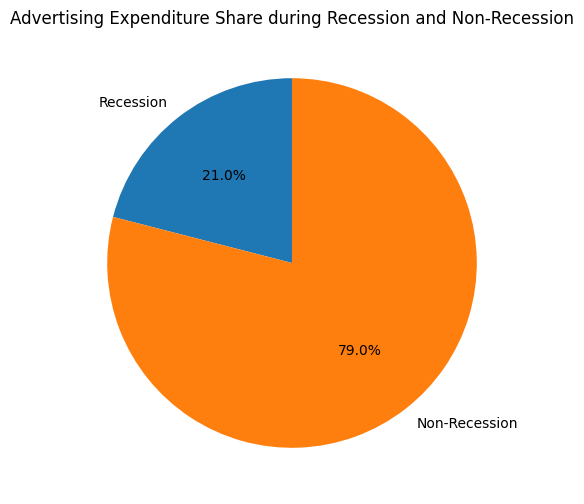

In [16]:
# Calculate total advertising expenditure for recession and non-recession periods
recession_ad_expenditure = df[df['Recession'] == 1]['Advertising_Expenditure'].sum()
non_recession_ad_expenditure = df[df['Recession'] == 0]['Advertising_Expenditure'].sum()

# Create the pie chart
labels = ['Recession', 'Non-Recession']
sizes = [recession_ad_expenditure, non_recession_ad_expenditure]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure Share during Recession and Non-Recession')
plt.show()

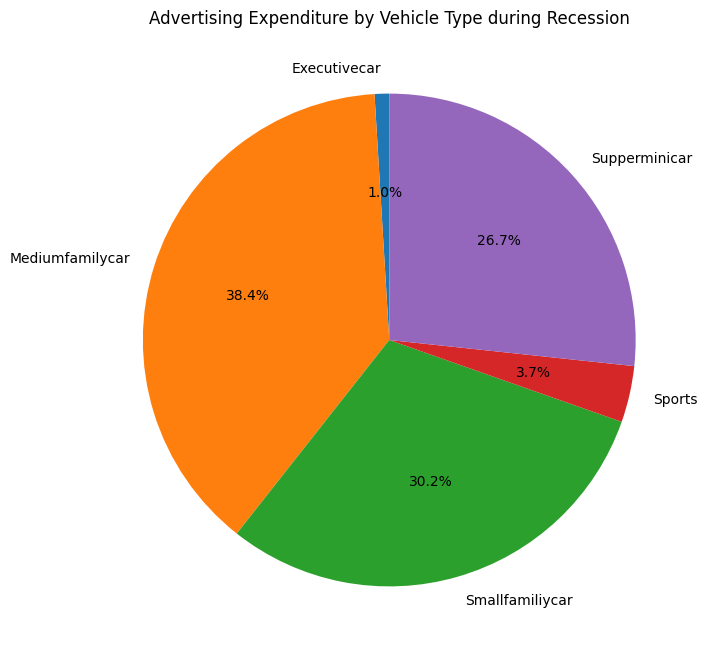

In [17]:
# Filter data for recession periods
recession_data = df[df['Recession'] == 1]

# Group data by vehicle type and sum advertising expenditure
vehicle_ad_expenditure = recession_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(vehicle_ad_expenditure, labels=vehicle_ad_expenditure.index, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure by Vehicle Type during Recession')
plt.show()

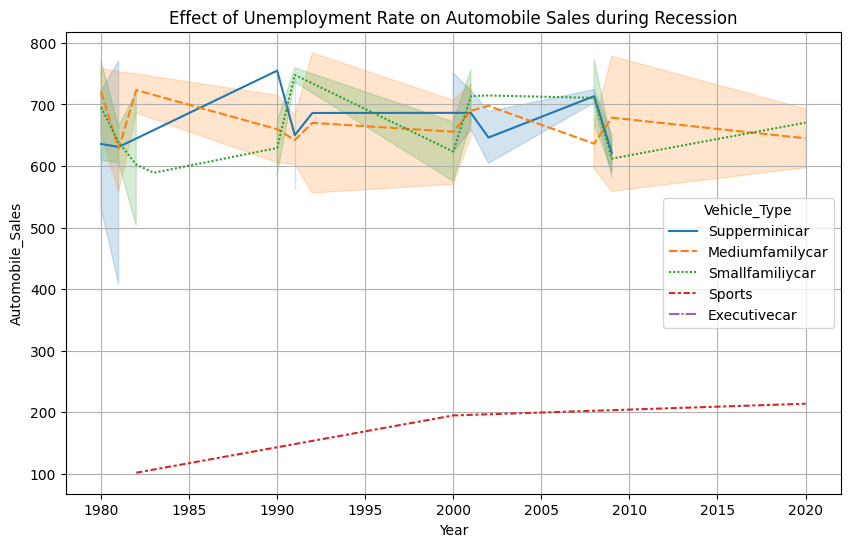

In [20]:

# Filter data for recession periods
recession_data = df[df['Recession'] == 1]

# Create the line plot
plt.figure(figsize=(10, 6))
# The 'style' parameter should use a column present in recession_data
# Here, I'm assuming 'Vehicle_Type' is suitable for styling, you might need to change it
sns.lineplot(x='Year', y='Automobile_Sales', hue='Vehicle_Type', style='Vehicle_Type', data=recession_data)
plt.title('Effect of Unemployment Rate on Automobile Sales during Recession')
plt.xlabel('Year')
plt.ylabel('Automobile_Sales')
plt.grid(True)
plt.show()

In [21]:
!pip install dash
!pip install pandas
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 19.9 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [ ]:
#Task 2.1: Titre significatif pour le tableau de bord
import dash
import dash.dcc as dcc
import dash.html as html

app = dash.Dash(__name__)

# Définir un titre significatif
app.title = "Tableau de Bord d'Analyse des Ventes Automobiles"

# Run the app
if __name__ == '__main__':
    app.run(debug=True) # Changed from app.run_server to app.run

In [38]:
# Task 2.2: Menus déroulants pour le type de véhicule et la plage d'années

app.layout = html.Div(children=[
    html.H1("Analyse des Ventes Automobiles"),

    # Menu déroulant pour le type de véhicule
    html.Div([
        html.Label("Type de Véhicule :"),
        dcc.Dropdown(
            id='vehicle-type-dropdown',
            options=[{'label': vehicle_type, 'value': vehicle_type} for vehicle_type in df['Vehicle_Type'].unique()],
            value=df['Vehicle_Type'].unique()[0]
        ),
    ]),

    # Menu déroulant pour la plage d'années
    html.Div([
        html.Label("Plage d'Années :"),
        dcc.RangeSlider(
            id='year-slider',
            min=df['Year'].min(),
            max=df['Year'].max(),
            step=1,
            value=[df['Year'].min(), df['Year'].max()],
            marks={str(year): str(year) for year in df['Year'].unique()}
        ),
    ]),
    # ... (reste du code) ...
])



In [28]:
# Task 2.3: Division de sortie pour afficher les graphiques

app.layout = html.Div(children=[
    # ... autres éléments du layout ...

    # Division pour afficher les graphiques
    html.Div(id='output-container', className='output-container'),
])

In [29]:
# Task 2.4: Fonction de rappel pour mettre à jour les graphiques

@app.callback(
    Output(component_id='output-container', component_property='children'),
    [Input(component_id='vehicle-type-dropdown', component_property='value'),
     Input(component_id='year-slider', component_property='value')]
)
def update_output(selected_vehicle_type, selected_year_range):
    # Logique pour filtrer les données et créer les graphiques ici
    # ...
    return # Les composants graphiques à afficher

In [30]:
# Task 2.5: Graphiques statistiques de la récession
# ... dans la fonction update_output ...

def update_output(selected_vehicle_type, selected_year_range):
    # ... (filtrage des données) ...

    # Graphique de la récession
    recession_fig = px.line(filtered_df, x="Year", y="Automobile_Sales",
                             color="Recession", title="Impact de la Récession sur les Ventes")

    # ... (autres graphiques et retour) ...

In [39]:
#Task 2.6: Graphiques statistiques annuels
# ... dans la fonction update_output ...
import dash
import dash.dcc as dcc
import dash.html as html
from dash.dependencies import Input, Output
import plotly.express as px

def update_output(selected_vehicle_type, selected_year_range):
    # ... (filtrage des données) ...

    # Filter data based on selected vehicle type and year range
    filtered_df = df[(df['Vehicle_Type'] == selected_vehicle_type) &
                     (df['Year'] >= selected_year_range[0]) &
                     (df['Year'] <= selected_year_range[1])]

    # Graphique des ventes annuelles
    yearly_sales_fig = px.bar(filtered_df.groupby('Year')['Automobile_Sales'].sum().reset_index(),
                                 x="Year", y="Automobile_Sales",
                                 title="Ventes Automobiles Annuelles")

    # Graphique de la récession
    recession_fig = px.line(filtered_df, x="Year", y="Automobile_Sales",
                             color="Recession", title="Impact de la Récession sur les Ventes")


     # Retourner les graphiques à afficher
    return [
        dcc.Graph(figure=recession_fig),
        dcc.Graph(figure=yearly_sales_fig)
    ]


app = dash.Dash(__name__)
app.title = "Tableau de Bord d'Analyse des Ventes Automobiles"

app.layout = html.Div(children=[
    html.H1("Analyse des Ventes Automobiles"),

    # Menu déroulant pour le type de véhicule
    html.Div([
        html.Label("Type de Véhicule :"),
        dcc.Dropdown(
            id='vehicle-type-dropdown',
            options=[{'label': vehicle_type, 'value': vehicle_type} for vehicle_type in df['Vehicle_Type'].unique()],
            value=df['Vehicle_Type'].unique()[0]
        ),
    ]),

    # Menu déroulant pour la plage d'années
    html.Div([
        html.Label("Plage d'Années :"),
        dcc.RangeSlider(
            id='year-slider',
            min=df['Year'].min(),
            max=df['Year'].max(),
            step=1,
            value=[df['Year'].min(), df['Year'].max()],
            marks={str(year): str(year) for year in df['Year'].unique()}
        ),
    ]),
    # ... (reste du code) ...
    html.Div(id='output-container', className='output-container'),
])

@app.callback(
    Output(component_id='output-container', component_property='children'),
    [Input(component_id='vehicle-type-dropdown', component_property='value'),
     Input(component_id='year-slider', component_property='value')]
)
def update_output_div(selected_vehicle_type, selected_year_range):
    return update_output(selected_vehicle_type, selected_year_range)

# Run the app
if __name__ == '__main__':
    app.run(debug=True) # Changed from app.run_server to app.run

<IPython.core.display.Javascript object>